# Using doper

The Doper module includes the `get_dopants` function. This function requires an input, which is a tuple of strings representing the ionic species of the material.

By default, the top five p-type and n-type candidates are reported. Use the `num_dopants` input to modify the number of outputs.

**Output Format**

The output is a dictionary with keys:
- "n-type cation substitutions"
- "p-type cation substitutions"
- "n-type anion substitutions"
- "p-type anion substitutions"

Each key contains a list of possible dopants, ordered by probability (Highest → Lowest). Each possible dopant is represented as a list with 6 components: `['substituted dopant', 'original species', 'probability', 'similarity', 'selectivity', 'combined score']`

In [ ]:
from smact.dopant_prediction.doper import Doper

# Define the material using its ionic species.
# Here, we are creating a material object with titanium in the 4+ oxidation state (Ti4+) and oxygen in the 2- oxidation state (O2-).
material = Doper(("Ti4+", "O2-"))

# Use the `get_dopants` function to predict potential dopants.
# By default, it returns the top 5 p-type and n-type dopants, but this can be adjusted with the `num_dopants` parameter.
# The output will be a dictionary with possible n-type and p-type cation and anion dopants.
dopants = material.get_dopants(num_dopants=5)

# Print only the top sorted dopants for each category.
# Each entry: [dopant_species, host_species, probability, similarity, selectivity, combined_score].
for category, results in dopants.items():
    print(f"\n{category}:")
    for entry in results["sorted"]:
        dopant, host, prob, sim, sel, combined = entry
        print(f"  [{dopant!r}, {host!r}, {prob:.4g}, {sim:.4g}, {sel:.4g}, {combined:.4g}]")


n-type cation substitutions:
  ['Ta5+', 'Ti4+', 8.79e-05, 1.85, 1, 1.637]
  ['Nb5+', 'Ti4+', 7.83e-05, 1.734, 1, 1.551]
  ['Sb5+', 'Ti4+', 6.259e-05, 1.51, 1, 1.383]
  ['Ru5+', 'Ti4+', 4.904e-05, 1.266, 1, 1.2]
  ['Re5+', 'Ti4+', 4.546e-05, 1.191, 1, 1.143]

p-type cation substitutions:
  ['Na1+', 'Ti4+', 0.0001006, 1.985, 1, 1.739]
  ['Zn2+', 'Ti4+', 8.564e-05, 1.824, 1, 1.618]
  ['Mn2+', 'Ti4+', 8.564e-05, 1.824, 1, 1.618]
  ['Mg2+', 'Ti4+', 6.777e-05, 1.59, 1, 1.442]
  ['Fe3+', 'Ti4+', 6.259e-05, 1.51, 1, 1.383]

n-type anion substitutions:
  ['F1-', 'O2-', 0.01508, 6.995, 1, 5.496]
  ['Cl1-', 'O2-', 0.004737, 5.837, 1, 4.628]
  ['Br1-', 'O2-', 0.001083, 4.361, 1, 3.521]
  ['I1-', 'O2-', 0.0007848, 4.039, 1, 3.279]

p-type anion substitutions:
  ['N3-', 'O2-', 0.001466, 4.664, 1, 3.748]


The results can be presented in a table format using the `to_table` attribute.

In [ ]:
table = material.to_table
lines = table.split('\n')
print('\n'.join(lines[:30]))
if len(lines) > 30:
    print(f'[... {len(lines) - 30} more lines ...]')

n-type cation substitutions
sorted
+--------+----------+--------+---------------+--------------+---------------+------------+
|   Rank | Dopant   | Host   |   Probability |   Similarity |   Selectivity |   Combined |
+========+==========+========+===============+==============+===============+============+
|      1 | Ta5+     | Ti4+   |   8.79037e-05 |      1.84999 |             1 |    1.63749 |
+--------+----------+--------+---------------+--------------+---------------+------------+
|      2 | Nb5+     | Ti4+   |   7.83004e-05 |      1.7343  |             1 |    1.55072 |
+--------+----------+--------+---------------+--------------+---------------+------------+
|      3 | Sb5+     | Ti4+   |   6.25917e-05 |      1.51038 |             1 |    1.38279 |
+--------+----------+--------+---------------+--------------+---------------+------------+
|      4 | Ru5+     | Ti4+   |   4.90413e-05 |      1.26641 |             1 |    1.19981 |
+--------+----------+--------+---------------+---------

Ternary and multicomponent systems can also be dealt with.

In [ ]:
quaternary = Doper(("Cu1+", "Zn2+", "Ge4+", "S2-"))
dopants = quaternary.get_dopants()
for category, results in dopants.items():
    print(f"\n{category}:")
    for entry in results["sorted"]:
        dopant, host, prob, sim, sel, combined = entry
        print(f"  [{dopant!r}, {host!r}, {prob:.4g}, {sim:.4g}, {sel:.4g}, {combined:.4g}]")


n-type cation substitutions:
  ['Si4+', 'Zn2+', 0.0002388, 2.849, 0.21, 2.19]
  ['Hg2+', 'Cu1+', 0.0002052, 2.698, 0.55, 2.161]
  ['Zn2+', 'Cu1+', 0.0002145, 2.742, 0.14, 2.092]
  ['Ge4+', 'Zn2+', 0.0001752, 2.54, 0.1, 1.93]
  ['P5+', 'Ge4+', 0.0001357, 2.285, 0.69, 1.886]

p-type cation substitutions:
  ['Na1+', 'Zn2+', 0.0002574, 2.925, 0.79, 2.391]
  ['Cu1+', 'Zn2+', 0.0002145, 2.742, 0.06, 2.072]
  ['Zn2+', 'Ge4+', 0.0001752, 2.54, 0.11, 1.932]
  ['K1+', 'Zn2+', 0.0001202, 2.163, 0.86, 1.837]
  ['Cd2+', 'Ge4+', 0.0001186, 2.15, 0.25, 1.675]

n-type anion substitutions:
  ['Cl1-', 'S2-', 0.0007087, 3.937, 1, 3.203]
  ['Br1-', 'S2-', 0.0003789, 3.311, 1, 2.733]
  ['I1-', 'S2-', 0.0003595, 3.259, 1, 2.694]
  ['F1-', 'S2-', 0.0002122, 2.731, 1, 2.298]

p-type anion substitutions:
  ['N3-', 'S2-', 0.0007863, 4.041, 1, 3.281]


If you want to plot the results in the form of heatmap, use `plot_dopants` method.

The default colormap is `'YlOrRd'`. Use the `cmap` parameter to choose a different colormap.

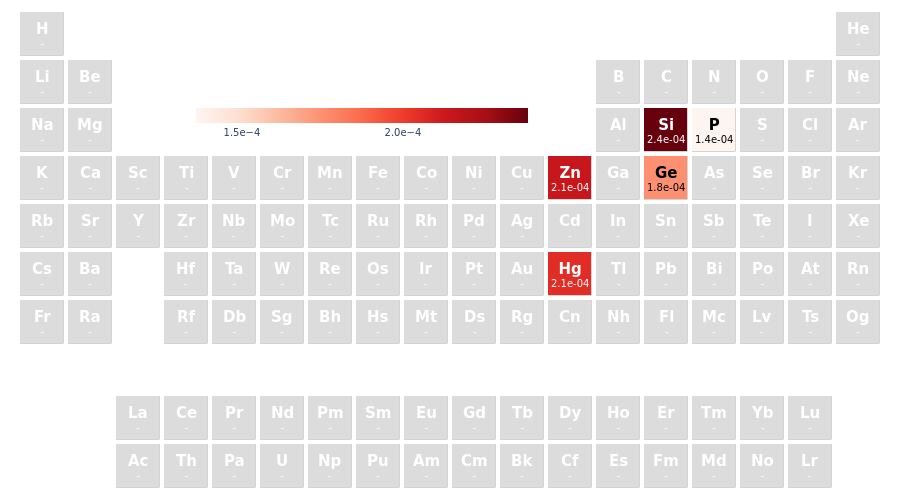

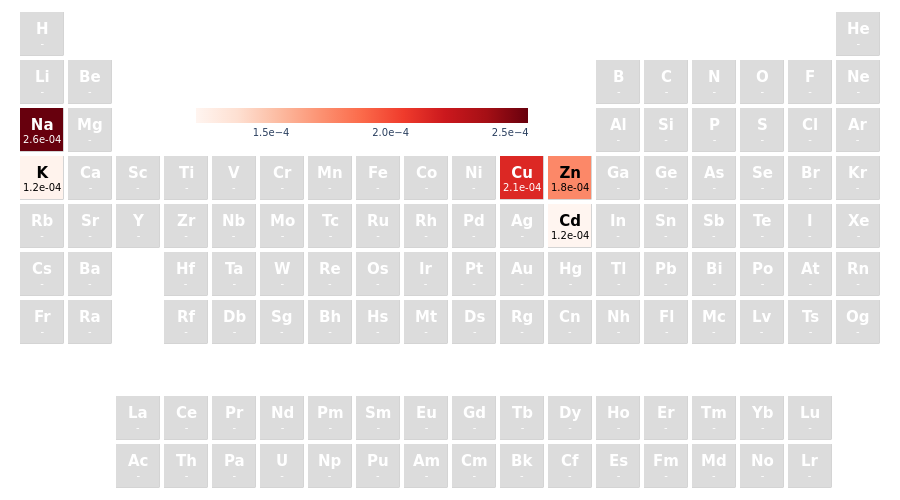

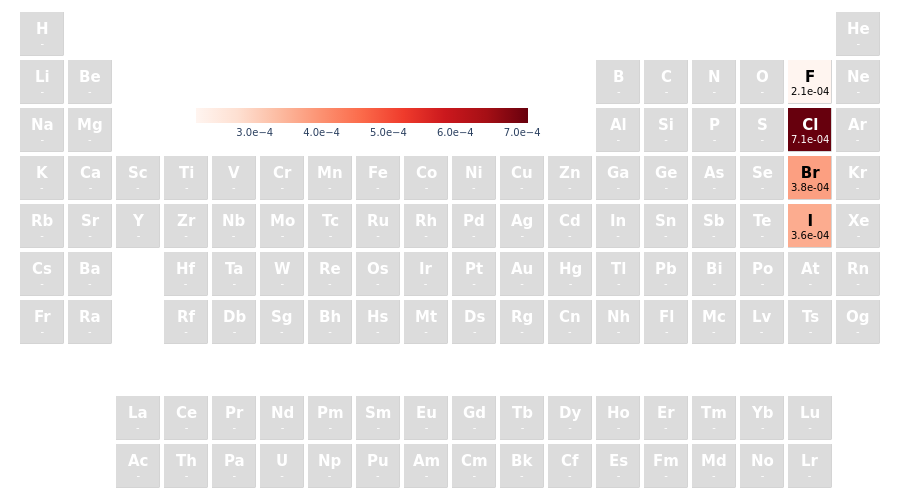

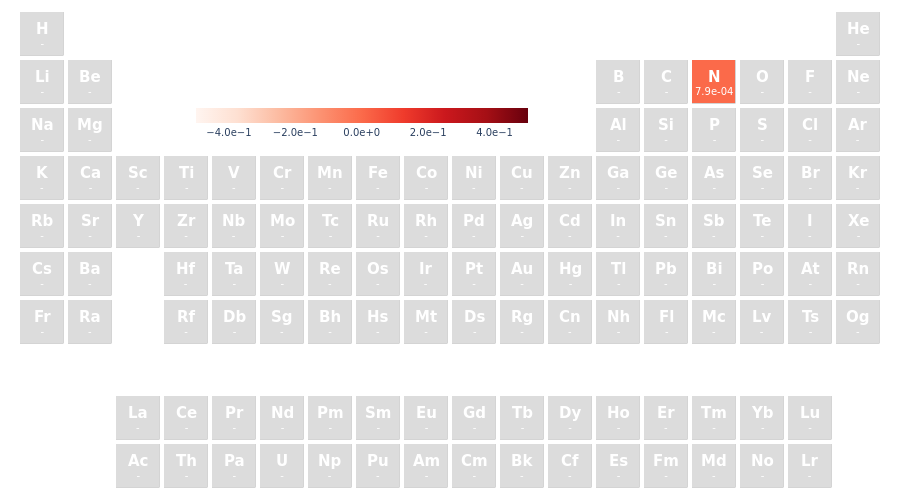

In [ ]:
import plotly.io as pio
pio.renderers.default = "png"
quaternary.plot_dopants(cmap="Reds")

## Alternative metrics

The probability values for the dopants are calculated based on the algorithm presented in:
        [Hautier, G., Fischer, C., Ehrlacher, V., Jain, A., and Ceder, G. (2011)
        Data Mined Ionic Substitutions for the Discovery of New Compounds.
        Inorganic Chemistry, 50(2), 656-663](https://pubs.acs.org/doi/10.1021/ic102031h)
        
In SMACT, we can also provide alternative ways for determining the possible dopants based on alternative probability or similarity metrics.

For example, we have a similarity metric based on distributed representations of the ions, which we call `skipspecies`. This metric is based on the idea that similar ions should have similar embeddings. The similarity is calculated based on the cosine similarity of the embeddings of the ions.

In [ ]:
doper_skipspecies = Doper(("Ti4+", "O2-"), embedding="skipspecies", use_probability=False)
doper_skipspecies.get_dopants(5)
# Present results in a table
table = doper_skipspecies.to_table
lines = table.split('\n')
print('\n'.join(lines[:30]))
if len(lines) > 30:
    print(f'[... {len(lines) - 30} more lines ...]')

n-type cation substitutions
sorted
+--------+----------+--------+---------------+--------------+---------------+------------+
|   Rank | Dopant   | Host   |   Probability |   Similarity |   Selectivity |   Combined |
+========+==========+========+===============+==============+===============+============+
|      1 | Nb5+     | Ti4+   |   1.87563e-05 |     0.82676  |             1 |   0.87007  |
+--------+----------+--------+---------------+--------------+---------------+------------+
|      2 | Ta5+     | Ti4+   |   1.69308e-05 |     0.724365 |             1 |   0.793274 |
+--------+----------+--------+---------------+--------------+---------------+------------+
|      3 | P5+      | Ti4+   |   1.49316e-05 |     0.598709 |             1 |   0.699032 |
+--------+----------+--------+---------------+--------------+---------------+------------+
|      4 | V5+      | Ti4+   |   1.47139e-05 |     0.584022 |             1 |   0.688017 |
+--------+----------+--------+---------------+---------